<a href="https://colab.research.google.com/github/tofighi/tutorials/blob/master/data-science/Chapter_6_Statistical_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Practical Statistics for Data Scientists (Python)
# Chapter 6. Statistical Machine Learning
> (c) 2019 Peter C. Bruce, Andrew Bruce, Peter Gedeck

In [1]:
!pip install dmba -q

Import required Python packages.

In [2]:
import math
import os
import random
from pathlib import Path
from collections import defaultdict
from itertools import product


import pandas as pd
import numpy as np

from sklearn import preprocessing
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
#from xgboost import XGBClassifier

from dmba import plotDecisionTree, textDecisionTree

import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

%matplotlib inline

Colab environment detected.


Define paths to data sets. If you don't keep your data in the same directory as the code, adapt the path names.

In [3]:
path = 'https://raw.githubusercontent.com/tofighi/BigData/refs/heads/main/datasets/data-science/'
LOAN200_CSV = path + 'loan200.csv'
LOAN3000_CSV =  path + 'loan3000.csv'
LOAN_DATA_CSV = path + 'loan_data.csv'

Set this if the notebook crashes in the XGBoost part.

In [4]:
#os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

# K-Nearest Neighbors
## A Small Example: Predicting Loan Default

In [5]:
# Import the loan data from a CSV file into a pandas DataFrame
loan200 = pd.read_csv(LOAN200_CSV)

# Define the predictor (feature) variables to use for modeling
predictors = ['payment_inc_ratio', 'dti']

# Define the outcome (target) variable
outcome = 'outcome'

# Select a single observation (the first row) for which we want to make a prediction
# Only the predictor columns are needed for this new instance
newloan = loan200.loc[0:0, predictors]

# Define the training data (excluding the first row)
# X contains the features, y contains the target variable
X = loan200.loc[1:, predictors]
y = loan200.loc[1:, outcome]

# Create a K-Nearest Neighbors classifier with 20 neighbors
knn = KNeighborsClassifier(n_neighbors=20)

# Fit the KNN model on the training data
knn.fit(X, y)

print("Classes:", knn.classes_)  # ['default' 'paid off']

# Use the trained model to predict the class label for the new loan
print(knn.predict(newloan))

# Print the predicted class probabilities for the new loan
print(knn.predict_proba(newloan))

Classes: ['default' 'paid off']
['paid off']
[[0.45 0.55]]


In [6]:
# Example: payment_inc_ratio = 3.2, dti = 15.7
newloan_vals = [[3.2, 15.7]]          # shape (1, 2)
print(knn.predict(newloan_vals))
print(knn.predict_proba(newloan_vals))


['paid off']
[[0.45 0.55]]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


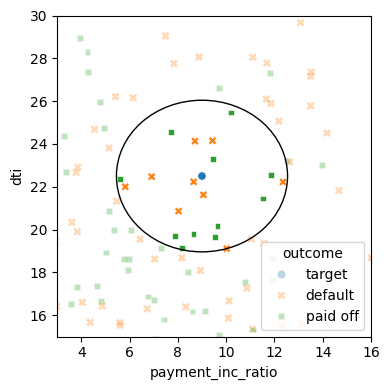

In [7]:
nbrs = knn.kneighbors(newloan)
maxDistance = np.max(nbrs[0][0])

fig, ax = plt.subplots(figsize=(4, 4))
sns.scatterplot(x='payment_inc_ratio', y='dti', style='outcome',
                hue='outcome', data=loan200, alpha=0.3, ax=ax)
sns.scatterplot(x='payment_inc_ratio', y='dti', style='outcome',
                hue='outcome',
                data=pd.concat([loan200.loc[0:0, :], loan200.loc[nbrs[1][0] + 1,:]]),
                ax=ax, legend=False)
ellipse = Ellipse(xy=newloan.values[0],
                  width=2 * maxDistance, height=2 * maxDistance,
                  edgecolor='black', fc='None', lw=1)
ax.add_patch(ellipse)
ax.set_xlim(3, 16)
ax.set_ylim(15, 30)

plt.tight_layout()
plt.show()

## Standardization (Normalization, Z-Scores)

In [8]:
# Create test case: first row as "new loan" to predict (preserves column names)
#The code loads loan data, prepares a new loan instance for prediction, trains
# a 5-NN classifier on the remaining data, and retrieves the 5 nearest neighbors to the new loan.

loan_data = pd.read_csv(LOAN_DATA_CSV)
loan_data = loan_data.drop(columns=['Unnamed: 0', 'status'])
# Categorical Encoding
loan_data['outcome'] = pd.Categorical(loan_data['outcome'],
                                      categories=['paid off', 'default'],
                                      ordered=True)


predictors = ['payment_inc_ratio', 'dti', 'revol_bal', 'revol_util']
outcome = 'outcome'

newloan = loan_data.loc[0:0, predictors]
print(newloan)
X = loan_data.loc[1:, predictors]
y = loan_data.loc[1:, outcome]

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X, y)

nbrs = knn.kneighbors(newloan)
# Display the 5 closest training loans (original scale) using neighbor indices
# The 5 closest training loans (indices ) are shown below on the original scale,
# demonstrating KNN's distance-based matching without scaling:
print(X.iloc[nbrs[1][0], :])


   payment_inc_ratio  dti  revol_bal  revol_util
0             2.3932  1.0       1687         9.4
       payment_inc_ratio   dti  revol_bal  revol_util
35536            1.47212  1.46       1686        10.0
33651            3.38178  6.37       1688         8.4
25863            2.36303  1.39       1691         3.5
42953            1.28160  7.14       1684         3.9
43599            4.12244  8.98       1684         7.2


The value of revol_bal in these neighbors is very close to its value in the new record, but the other predictor variables are all over the map and essentially play no role in determining neighbors.

These neighbors vary notably in payment_inc_ratio (0.18–0.99) and dti (0.61–34.63), highlighting how revol_bal heavily influences distances here due to its larger scale.

In [9]:
# Create training data: all rows except first (features X, target y)
newloan = loan_data.loc[0:0, predictors]

X = loan_data.loc[1:, predictors]
y = loan_data.loc[1:, outcome]
# Initialize StandardScaler for feature standardization (mean=0, std=1)
scaler = preprocessing.StandardScaler()
# Fit scaler on training features (X * 1.0 ensures float conversion)
scaler.fit(X * 1.0)
# Transform training data to standardized scale
X_std = scaler.transform(X * 1.0)

# Transform new loan to same standardized scale (critical for distance-based KNN!)
newloan_std = scaler.transform(newloan * 1.0)
# Create KNN classifier with k=5 nearest neighbors
knn = KNeighborsClassifier(n_neighbors=5)
# Train KNN on standardized training data
knn.fit(X_std, y)
# Find 5 nearest neighbors for new loan and get their distances + indices

nbrs = knn.kneighbors(newloan_std)
# Display the 5 closest training loans (original scale) using neighbor indices
print(X.iloc[nbrs[1][0], :])

       payment_inc_ratio   dti  revol_bal  revol_util
2080             2.61091  1.03       1218         9.7
1438             2.34343  0.51        278         9.9
30215            2.71200  1.34       1075         8.5
28542            2.39760  0.74       2917         7.4
44737            2.34309  1.37        488         7.2


# Tree Models
## A Simple Example
The package _scikit-learn_ has the class `DecisionTreeClassifier` to build a decision tree model. The function `plotDecisionTree` from the _dmba_ package can be used to visualize the tree.

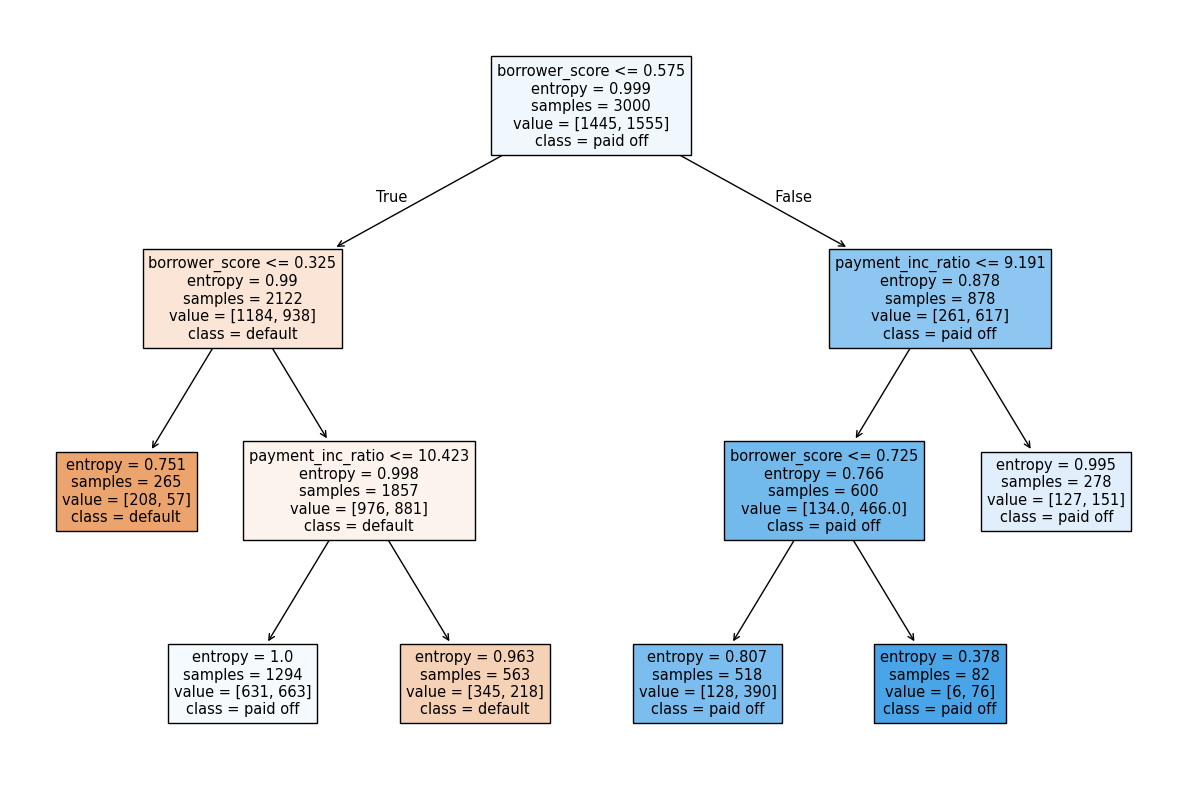

In [10]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
loan3000 = pd.read_csv(LOAN3000_CSV)

predictors = ['borrower_score', 'payment_inc_ratio']
outcome = 'outcome'

X = loan3000[predictors]
y = loan3000[outcome]

loan_tree = DecisionTreeClassifier(random_state=1, criterion='entropy',
                                   min_impurity_decrease=0.003)
loan_tree.fit(X, y)
#plotDecisionTree(loan_tree, feature_names=predictors, class_names=loan_tree.classes_)


plt.figure(figsize=(15,10))
plot_tree(loan_tree,
          feature_names=predictors,
          class_names=loan_tree.classes_,
          filled=True,
          max_depth=3)  # Limit depth for readability
plt.show()

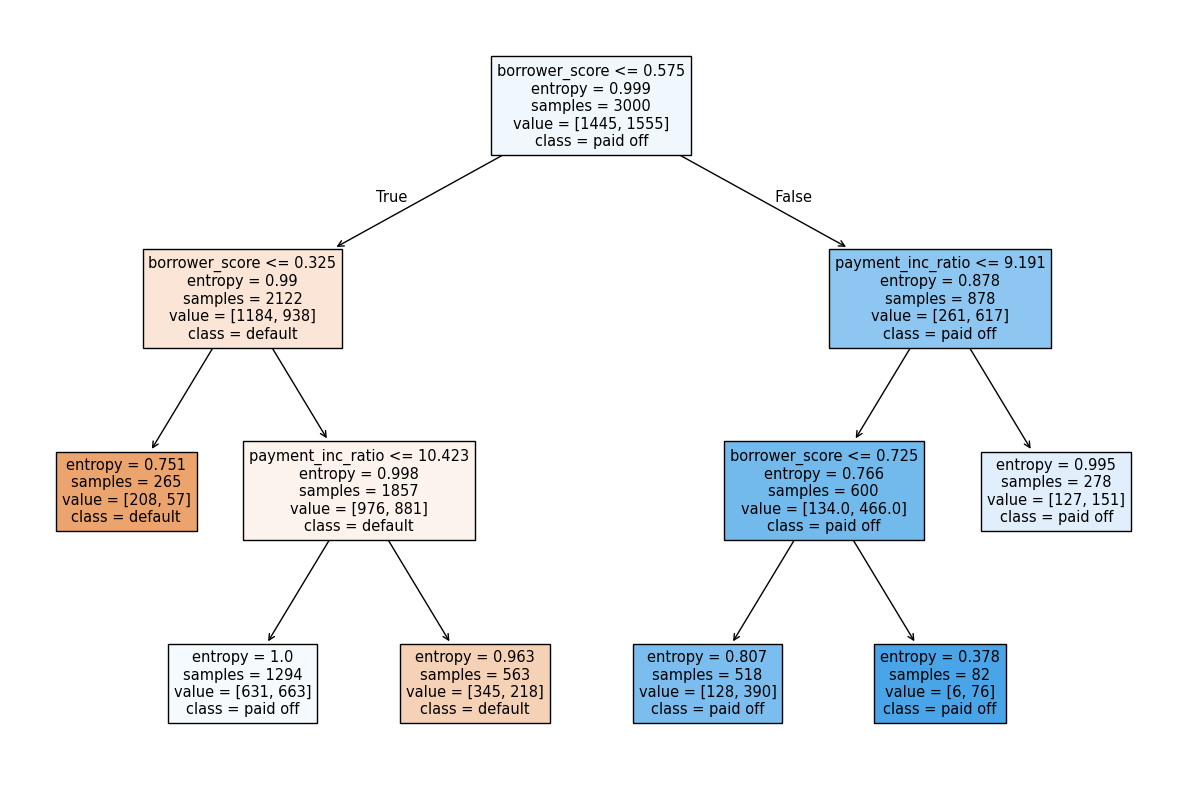

In [11]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Load subset of loan data (3000 samples) for faster tree visualization
loan3000 = pd.read_csv(LOAN3000_CSV)

# Select key predictors: borrower_score (creditworthiness), payment_inc_ratio (affordability risk)
predictors = ['borrower_score', 'payment_inc_ratio']
outcome = 'outcome'

# Create feature matrix X and target vector y for tree training
X = loan3000[predictors]
y = loan3000[outcome]

# Initialize decision tree with entropy criterion (information gain) for interpretable splits
# min_impurity_decrease=0.003 prevents overly bushy trees; random_state for reproducibility
loan_tree = DecisionTreeClassifier(random_state=1, criterion='entropy',
                                   min_impurity_decrease=0.003)
loan_tree.fit(X, y)  # Train tree on loan features to predict default vs paid_off

# Create large figure for readable tree visualization
plt.figure(figsize=(15,10))
# Plot tree: feature_names label splits, class_names show outcomes, filled=True colors by class,
# max_depth=3 limits to top splits (full tree too complex for slides)
plot_tree(loan_tree,
          feature_names=predictors,
          class_names=loan_tree.classes_,
          filled=True,
          max_depth=3)
plt.show()  # Display the decision tree visualization


In [12]:
print(textDecisionTree(loan_tree))

node=0 test node: go to node 1 if 0 <= 0.5750000178813934 else to node 6
  node=1 test node: go to node 2 if 0 <= 0.32500000298023224 else to node 3
    node=2 leaf node: [[np.float64(0.785), np.float64(0.215)]]
    node=3 test node: go to node 4 if 1 <= 10.42264986038208 else to node 5
      node=4 leaf node: [[np.float64(0.488), np.float64(0.512)]]
      node=5 leaf node: [[np.float64(0.613), np.float64(0.387)]]
  node=6 test node: go to node 7 if 1 <= 9.19082498550415 else to node 10
    node=7 test node: go to node 8 if 0 <= 0.7249999940395355 else to node 9
      node=8 leaf node: [[np.float64(0.247), np.float64(0.753)]]
      node=9 leaf node: [[np.float64(0.073), np.float64(0.927)]]
    node=10 leaf node: [[np.float64(0.457), np.float64(0.543)]]


## The Recursive Partitioning Algorithm - Extra

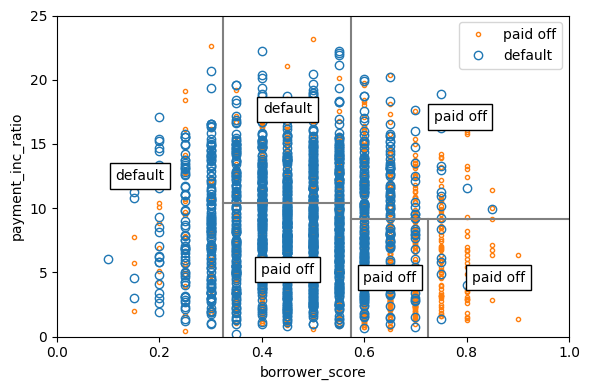

In [13]:
fig, ax = plt.subplots(figsize=(6, 4))

loan3000.loc[loan3000.outcome=='paid off'].plot(
    x='borrower_score', y='payment_inc_ratio', style='.',
    markerfacecolor='none', markeredgecolor='C1', ax=ax)
loan3000.loc[loan3000.outcome=='default'].plot(
    x='borrower_score', y='payment_inc_ratio', style='o',
    markerfacecolor='none', markeredgecolor='C0', ax=ax)
ax.legend(['paid off', 'default']);
ax.set_xlim(0, 1)
ax.set_ylim(0, 25)
ax.set_xlabel('borrower_score')
ax.set_ylabel('payment_inc_ratio')

x0 = 0.575
x1a = 0.325; y1b = 9.191
y2a = 10.423; x2b = 0.725
ax.plot((x0, x0), (0, 25), color='grey')
ax.plot((x1a, x1a), (0, 25), color='grey')
ax.plot((x0, 1), (y1b, y1b), color='grey')
ax.plot((x1a, x0), (y2a, y2a), color='grey')
ax.plot((x2b, x2b), (0, y1b), color='grey')

labels = [('default', (x1a / 2, 25 / 2)),
          ('default', ((x0 + x1a) / 2, (25 + y2a) / 2)),
          ('paid off', ((x0 + x1a) / 2, y2a / 2)),
          ('paid off', ((1 + x0) / 2, (y1b + 25) / 2)),
          ('paid off', ((1 + x2b) / 2, (y1b + 0) / 2)),
          ('paid off', ((x0 + x2b) / 2, (y1b + 0) / 2)),
         ]
for label, (x, y) in labels:
    ax.text(x, y, label, bbox={'facecolor':'white'},
            verticalalignment='center', horizontalalignment='center')

plt.tight_layout()
plt.show()

## Measuring Homogeneity or Impurity - Extra

In [14]:
def entropyFunction(x):
    if x == 0: return 0
    return -x * math.log(x, 2) - (1 - x) * math.log(1 - x, 2)

def giniFunction(x):
    return x * (1 - x)

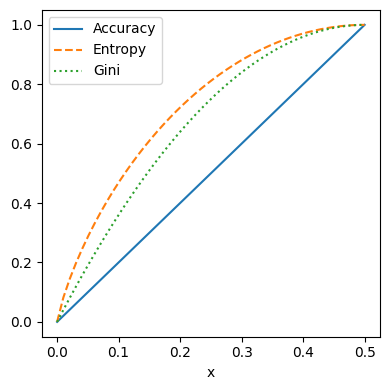

In [15]:
x = np.linspace(0, 0.5, 50)
impure = pd.DataFrame({
    'x': x,
    'Accuracy': 2 * x,
    'Gini': [giniFunction(xi) / giniFunction(.5) for xi in x],
    'Entropy': [entropyFunction(xi) for xi in x],
})

fig, ax = plt.subplots(figsize=(4, 4))

impure.plot(x='x', y='Accuracy', ax=ax, linestyle='solid')
impure.plot(x='x', y='Entropy', ax=ax, linestyle='--')
impure.plot(x='x', y='Gini', ax=ax, linestyle=':')

plt.tight_layout()
plt.show()

# Bagging and the Random Forest
## Random Forest

In [16]:
# Select key predictors for random forest: borrower_score (credit risk), payment_inc_ratio (affordability)
predictors = ['borrower_score', 'payment_inc_ratio']
outcome = 'outcome'

# Create feature matrix X and target vector y for ensemble training
X = loan3000[predictors]
y = loan3000[outcome]

# Initialize random forest with 500 trees for stable predictions
# max_features = √P    where P = # predictors - by defualt it is 1
# random_state=1 ensures reproducible splits; oob_score=True enables out-of-bag validation
rf = RandomForestClassifier(n_estimators=500, random_state=1, max_features=1,
                            oob_score=True)
rf.fit(X, y)  # Train ensemble on all loans

# Print out-of-bag (OOB) decision scores for each training sample
# Shape: (n_samples, n_classes) with probabilities for 'paid off' vs 'default'
print(rf.oob_decision_function_)


[[0.18131868 0.81868132]
 [0.26704545 0.73295455]
 [0.93333333 0.06666667]
 ...
 [1.         0.        ]
 [0.73157895 0.26842105]
 [0.68085106 0.31914894]]


In [17]:
# Test n_estimators from 20 to 500 trees (step=5) to find optimal forest size
n_estimators = list(range(20, 510, 5))

# Store OOB accuracy for each forest size
oobScores = []
for n in n_estimators:
    # Train RF with fixed max_depth=5 (prevents overfitting), entropy splitting
    rf = RandomForestClassifier(n_estimators=n,        # Varying # trees
                                criterion='entropy',   # Information gain splitting
                                max_depth=5,           # Limit depth for generalization
                                random_state=1,        # Reproducible splits
                                oob_score=True)        # Enable OOB validation
    rf.fit(X, y)                       # Train on full loan data
    oobScores.append(rf.oob_score_)    # Record OOB accuracy


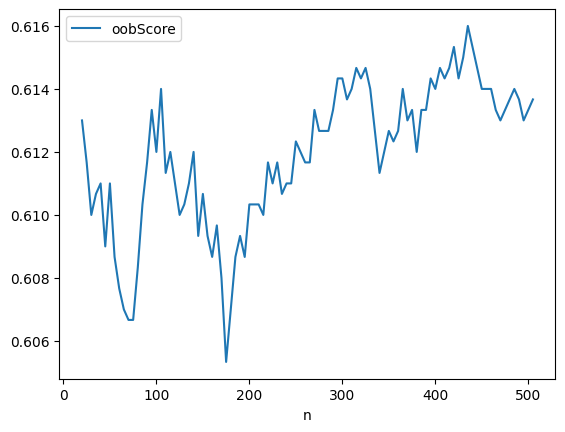

In [18]:
pd.DataFrame({
    'n': n_estimators,
    'oobScore': oobScores
}).plot(x='n', y='oobScore')
plt.show()

In [19]:
import pandas as pd
import numpy as np  # if generating sample data

# Assuming n_estimator and oobScores from your RF loop
df = pd.DataFrame({'n': n_estimators, 'oobScore': oobScores})

# Find best
best_idx = df['oobScore'].idxmax()
best_accuracy = df.loc[best_idx, 'oobScore']
best_n = df.loc[best_idx, 'n']

print(f"Best OOB accuracy: {best_accuracy:.4f}")
print(f"Equivalent number of trees (n_estimators): {best_n}")


Best OOB accuracy: 0.6160
Equivalent number of trees (n_estimators): 435


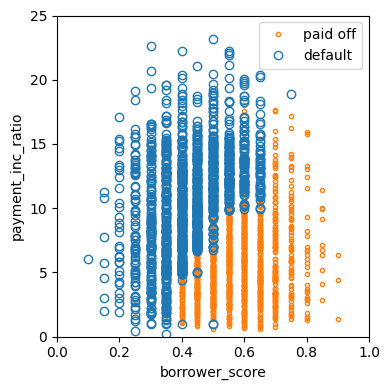

In [20]:
predictions = X.copy()
predictions['prediction'] = rf.predict(X)
predictions.head()

fig, ax = plt.subplots(figsize=(4, 4))

predictions.loc[predictions.prediction=='paid off'].plot(
    x='borrower_score', y='payment_inc_ratio', style='.',
    markerfacecolor='none', markeredgecolor='C1', ax=ax)
predictions.loc[predictions.prediction=='default'].plot(
    x='borrower_score', y='payment_inc_ratio', style='o',
    markerfacecolor='none', markeredgecolor='C0', ax=ax)
ax.legend(['paid off', 'default']);
ax.set_xlim(0, 1)
ax.set_ylim(0, 25)
ax.set_xlabel('borrower_score')
ax.set_ylabel('payment_inc_ratio')

plt.tight_layout()
plt.show()

## Variable importance
The following code prepares loan default prediction data and trains two Random Forest classifiers to compare default criteria (Gini vs. entropy).

Gini vs. Entropy refers to the two split criteria used in decision trees (and thus Random Forests) to  choose the best feature splits.

Gini (default in scikit-learn) is faster and measures misclassification probability: lower when a node is pure (one class dominates).

In [21]:
predictors = ['loan_amnt', 'term', 'annual_inc', 'dti',
              'payment_inc_ratio', 'revol_bal', 'revol_util',
              'purpose', 'delinq_2yrs_zero', 'pub_rec_zero',
              'open_acc', 'grade', 'emp_length', 'purpose_',
              'home_', 'emp_len_', 'borrower_score']
outcome = 'outcome'

X = pd.get_dummies(loan_data[predictors], drop_first=True, dtype=int)
y = loan_data[outcome]

rf_all = RandomForestClassifier(n_estimators=500, random_state=1)
print(rf_all.fit(X, y))

rf_all_entropy = RandomForestClassifier(n_estimators=500, random_state=1,
                                        criterion='entropy')
print(rf_all_entropy.fit(X, y))

RandomForestClassifier(n_estimators=500, random_state=1)
RandomForestClassifier(criterion='entropy', n_estimators=500, random_state=1)


In [22]:
rf = RandomForestClassifier(n_estimators=500)
scores = defaultdict(list)

# crossvalidate the scores on a number of different random splits of the data
for _ in range(3):
    train_X, valid_X, train_y, valid_y = train_test_split(X, y,
                                                          test_size=0.3)
    rf.fit(train_X, train_y)
    acc = metrics.accuracy_score(valid_y, rf.predict(valid_X))
    for column in X.columns:
        X_t = valid_X.copy()
        X_t[column] = np.random.permutation(X_t[column].values)
        shuff_acc = metrics.accuracy_score(valid_y, rf.predict(X_t))
        scores[column].append((acc-shuff_acc)/acc)
print('Features sorted by their score:')
print(sorted([(round(np.mean(score), 4), feat) for
              feat, score in scores.items()], reverse=True))

Features sorted by their score:
[(np.float64(0.0741), 'borrower_score'), (np.float64(0.0367), 'grade'), (np.float64(0.0248), 'term_60 months'), (np.float64(0.0112), 'annual_inc'), (np.float64(0.0096), 'payment_inc_ratio'), (np.float64(0.0035), 'purpose__small_business'), (np.float64(0.0027), 'purpose_small_business'), (np.float64(0.0023), 'dti'), (np.float64(0.0021), 'home__RENT'), (np.float64(0.0018), 'revol_bal'), (np.float64(0.0017), 'purpose_credit_card'), (np.float64(0.001), 'emp_len__ > 1 Year'), (np.float64(0.0009), 'open_acc'), (np.float64(0.0006), 'pub_rec_zero'), (np.float64(0.0004), 'revol_util'), (np.float64(0.0003), 'purpose__other'), (np.float64(0.0002), 'purpose_wedding'), (np.float64(0.0002), 'delinq_2yrs_zero'), (np.float64(0.0001), 'purpose_medical'), (np.float64(-0.0), 'purpose_major_purchase'), (np.float64(0.0), 'purpose_house'), (np.float64(-0.0), 'home__OWN'), (np.float64(-0.0001), 'purpose_moving'), (np.float64(-0.0001), 'purpose__medical'), (np.float64(-0.0002),

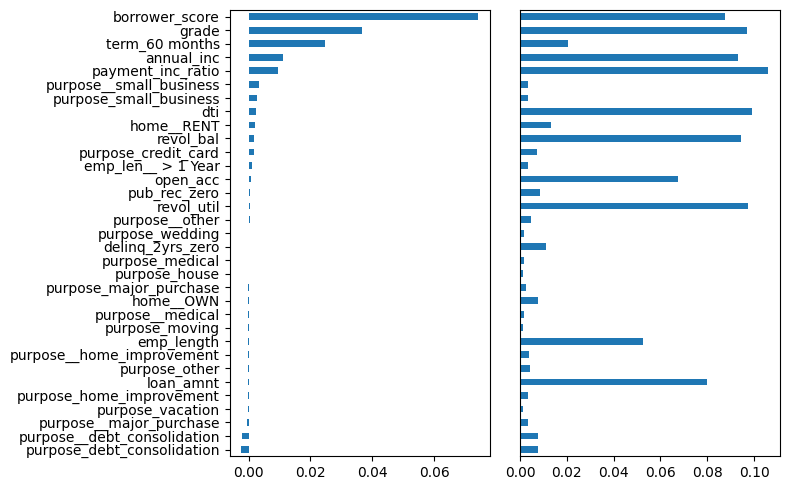

In [23]:
importances = rf_all.feature_importances_

df = pd.DataFrame({
    'feature': X.columns,
    'Accuracy decrease': [np.mean(scores[column]) for column in
                         X.columns],
    'Gini decrease': rf_all.feature_importances_,
    'Entropy decrease': rf_all_entropy.feature_importances_,
})
df = df.sort_values('Accuracy decrease')

fig, axes = plt.subplots(ncols=2, figsize=(8, 5))
ax = df.plot(kind='barh', x='feature', y='Accuracy decrease',
             legend=False, ax=axes[0])
ax.set_ylabel('')

ax = df.plot(kind='barh', x='feature', y='Gini decrease',
             legend=False, ax=axes[1])
ax.set_ylabel('')
ax.get_yaxis().set_visible(False)

plt.tight_layout()
plt.show()

# Boosting - Extra
## XGBoost

In [25]:
from xgboost import XGBClassifier

predictors = ['borrower_score', 'payment_inc_ratio']
outcome = 'outcome'

X = loan3000[predictors]
y = pd.Series([1 if o == 'default' else 0 for o in loan3000[outcome]])

xgb = XGBClassifier(objective='binary:logistic', subsample=.63,
                    eval_metric='error')
print(xgb.fit(X, y))

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='error', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)


In [26]:
xgb_df = X.copy()
xgb_df['prediction'] = ['default' if p == 1 else 'paid off' for p in xgb.predict(X)]
xgb_df['prob_default'] = xgb.predict_proba(X)[:, 0]
print(xgb_df.head())

   borrower_score  payment_inc_ratio prediction  prob_default
0            0.40            5.11135   paid off      0.586677
1            0.40            5.43165    default      0.307408
2            0.70            9.23003    default      0.337050
3            0.40            2.33482   paid off      0.861774
4            0.45           12.10320    default      0.056794


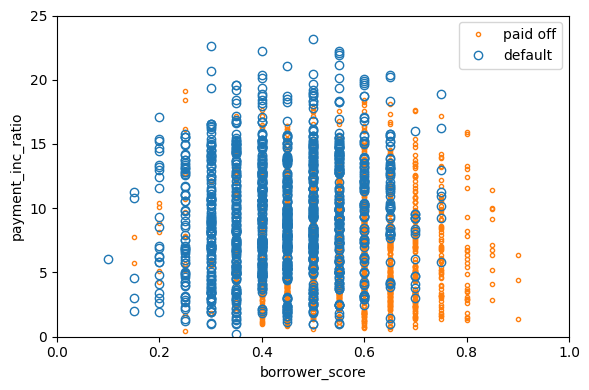

In [27]:
fig, ax = plt.subplots(figsize=(6, 4))

xgb_df.loc[xgb_df.prediction=='paid off'].plot(
    x='borrower_score', y='payment_inc_ratio', style='.',
    markerfacecolor='none', markeredgecolor='C1', ax=ax)
xgb_df.loc[xgb_df.prediction=='default'].plot(
    x='borrower_score', y='payment_inc_ratio', style='o',
    markerfacecolor='none', markeredgecolor='C0', ax=ax)
ax.legend(['paid off', 'default']);
ax.set_xlim(0, 1)
ax.set_ylim(0, 25)
ax.set_xlabel('borrower_score')
ax.set_ylabel('payment_inc_ratio')

plt.tight_layout()
plt.show()

In [28]:
predictors = ['loan_amnt', 'term', 'annual_inc', 'dti',
              'payment_inc_ratio', 'revol_bal', 'revol_util',
              'purpose', 'delinq_2yrs_zero', 'pub_rec_zero',
              'open_acc', 'grade', 'emp_length', 'purpose_',
              'home_', 'emp_len_', 'borrower_score']
outcome = 'outcome'

X = pd.get_dummies(loan_data[predictors], drop_first=True, dtype=int)
y = pd.Series([1 if o == 'default' else 0 for o in loan_data[outcome]])

train_X, valid_X, train_y, valid_y = train_test_split(X, y, test_size=10000)

xgb_default = XGBClassifier(objective='binary:logistic', n_estimators=250, max_depth=6,
                            reg_lambda=0, learning_rate=0.3, subsample=1,
                            eval_metric='error')
xgb_default.fit(train_X, train_y)

xgb_penalty = XGBClassifier(objective='binary:logistic', n_estimators=250, max_depth=6,
                            reg_lambda=1000, learning_rate=0.1, subsample=0.63,
                            eval_metric='error')
print(xgb_penalty.fit(train_X, train_y))

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='error', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=250,
              n_jobs=None, num_parallel_tree=None, ...)


## Regularization: Avoiding Overfitting - Extra

In [29]:
pred_default = xgb_default.predict_proba(train_X)[:, 1]
error_default = abs(train_y - pred_default) > 0.5
print('default (train): ', np.mean(error_default))

pred_default = xgb_default.predict_proba(valid_X)[:, 1]
error_default = abs(valid_y - pred_default) > 0.5
print('default: ', np.mean(error_default))

pred_penalty = xgb_penalty.predict_proba(valid_X)[:, 1]
error_penalty = abs(valid_y - pred_penalty) > 0.5
print('penalty: ', np.mean(error_penalty))

default (train):  0.10355950427253692
default:  0.3578
penalty:  0.3257


In [30]:
results = []
for ntree_limit in range(1, 250):
    iteration_range = [1, ntree_limit + 1]
    train_default = xgb_default.predict_proba(train_X, iteration_range=iteration_range)[:, 1]
    train_penalty = xgb_penalty.predict_proba(train_X, iteration_range=iteration_range)[:, 1]
    pred_default = xgb_default.predict_proba(valid_X, iteration_range=iteration_range)[:, 1]
    pred_penalty = xgb_penalty.predict_proba(valid_X, iteration_range=iteration_range)[:, 1]
    results.append({
        'iterations': ntree_limit,
        'default train': np.mean(abs(train_y - train_default) > 0.5),
        'penalty train': np.mean(abs(train_y - train_penalty) > 0.5),
        'default test': np.mean(abs(valid_y - pred_default) > 0.5),
        'penalty test': np.mean(abs(valid_y - pred_penalty) > 0.5),
    })

results = pd.DataFrame(results)
print(results.head())

   iterations  default train  penalty train  default test  penalty test
0           1       0.340813       0.341067        0.3488        0.3454
1           2       0.330117       0.339766        0.3435        0.3404
2           3       0.326580       0.338011        0.3408        0.3376
3           4       0.321912       0.336370        0.3371        0.3399
4           5       0.318460       0.336625        0.3353        0.3404


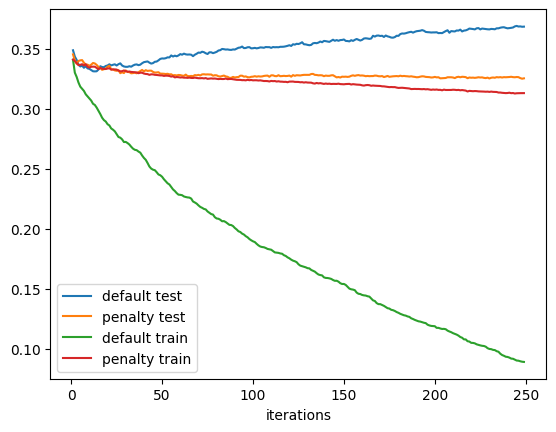

In [31]:
ax = results.plot(x='iterations', y='default test')
results.plot(x='iterations', y='penalty test', ax=ax)
results.plot(x='iterations', y='default train', ax=ax)
results.plot(x='iterations', y='penalty train', ax=ax)
plt.show()

## Hyperparameters and Cross-Validation - Extra

In [32]:
idx = np.random.choice(range(5), size=len(X), replace=True)
error = []
for eta, max_depth in product([0.1, 0.5, 0.9], [3, 6, 9]):
    xgb = XGBClassifier(objective='binary:logistic', n_estimators=250,
                        max_depth=max_depth, learning_rate=eta,
                        eval_metric='error')
    cv_error = []
    for k in range(5):
        fold_idx = idx == k
        train_X = X.loc[~fold_idx]; train_y = y[~fold_idx]
        valid_X = X.loc[fold_idx]; valid_y = y[fold_idx]

        xgb.fit(train_X, train_y)
        pred = xgb.predict_proba(valid_X)[:, 1]
        cv_error.append(np.mean(abs(valid_y - pred) > 0.5))
    error.append({
        'eta': eta,
        'max_depth': max_depth,
        'avg_error': np.mean(cv_error)
    })
    print(error[-1])
errors = pd.DataFrame(error)
print(errors)

{'eta': 0.1, 'max_depth': 3, 'avg_error': np.float64(0.3282768604054062)}
{'eta': 0.1, 'max_depth': 6, 'avg_error': np.float64(0.33363737795238124)}
{'eta': 0.1, 'max_depth': 9, 'avg_error': np.float64(0.3460371241211678)}
{'eta': 0.5, 'max_depth': 3, 'avg_error': np.float64(0.3376592252788239)}
{'eta': 0.5, 'max_depth': 6, 'avg_error': np.float64(0.3706925493134558)}
{'eta': 0.5, 'max_depth': 9, 'avg_error': np.float64(0.3713576478520285)}
{'eta': 0.9, 'max_depth': 3, 'avg_error': np.float64(0.35257349419028605)}
{'eta': 0.9, 'max_depth': 6, 'avg_error': np.float64(0.3916611899641376)}
{'eta': 0.9, 'max_depth': 9, 'avg_error': np.float64(0.38073200366281146)}
   eta  max_depth  avg_error
0  0.1          3   0.328277
1  0.1          6   0.333637
2  0.1          9   0.346037
3  0.5          3   0.337659
4  0.5          6   0.370693
5  0.5          9   0.371358
6  0.9          3   0.352573
7  0.9          6   0.391661
8  0.9          9   0.380732


In [33]:
print(errors.pivot_table(index='eta', columns='max_depth', values='avg_error') * 100)

max_depth          3          6          9
eta                                       
0.1        32.827686  33.363738  34.603712
0.5        33.765923  37.069255  37.135765
0.9        35.257349  39.166119  38.073200
